In [2]:
from cProfile import label

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [9]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

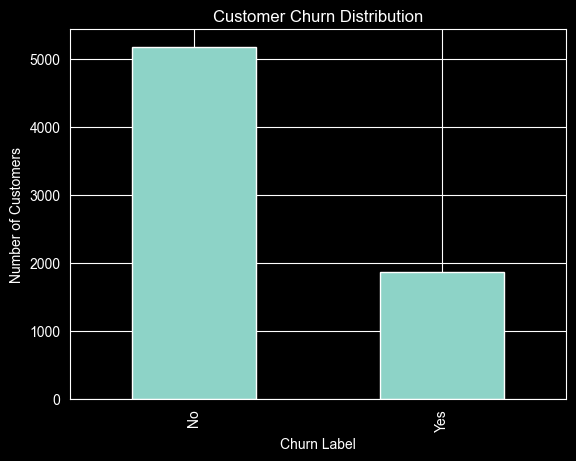

In [12]:
df["Churn Label"].value_counts().plot(kind="bar")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.show()

In [13]:
df.columns.tolist()

['CustomerID',
 'Count',
 'Country',
 'State',
 'City',
 'Zip Code',
 'Lat Long',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Churn Reason']

In [14]:
pd.crosstab(df["Gender"], df["Churn Label"])

Churn Label,No,Yes
Gender,,
Female,2549,939
Male,2625,930


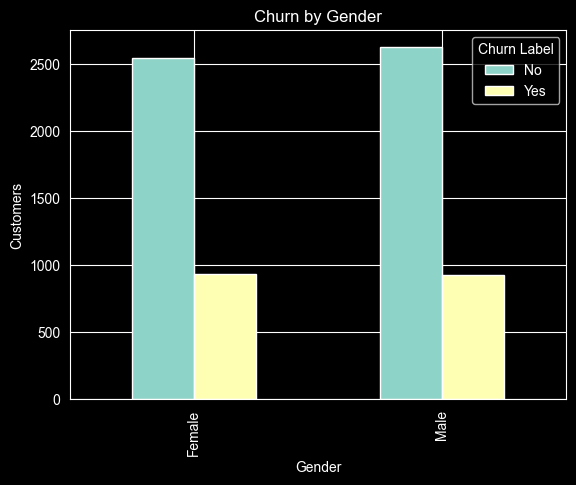

In [15]:
pd.crosstab(df["Gender"], df["Churn Label"]).plot(kind="bar")

plt.title("Churn by Gender")
plt.ylabel("Customers")
plt.show()

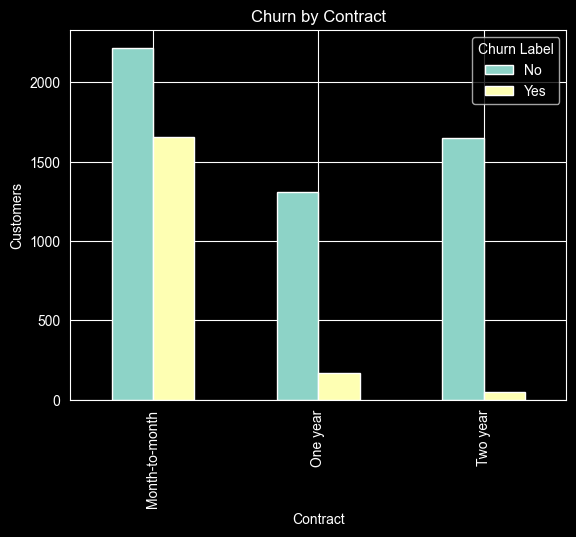

In [16]:
pd.crosstab(df["Contract"], df["Churn Label"]).plot(kind="bar")

plt.title("Churn by Contract")
plt.ylabel("Customers")
plt.show()

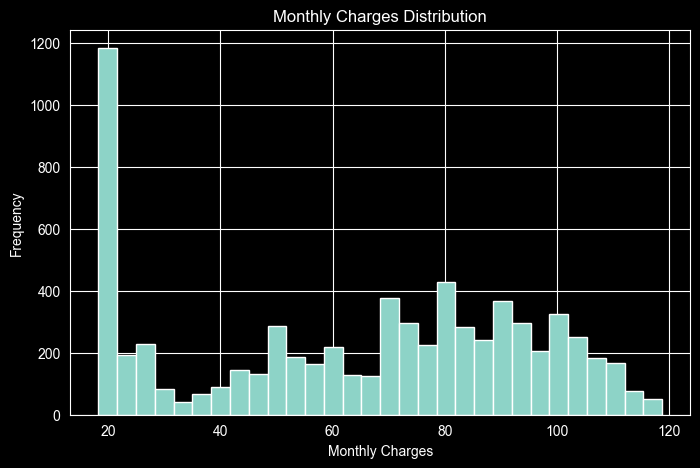

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Monthly Charges"], bins=30)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

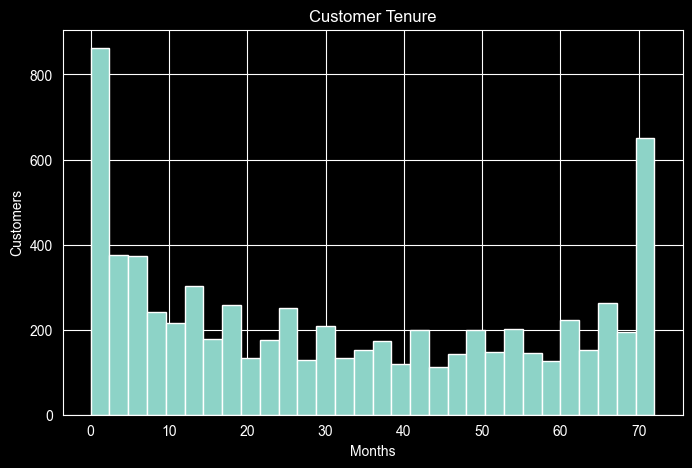

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df["Tenure Months"], bins=30)

plt.title("Customer Tenure")
plt.xlabel("Months")
plt.ylabel("Customers")

plt.show()

In [19]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

In [20]:


df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'CLTV']

In [21]:
y = df["Churn Label"]
X = df.drop("Churn Label", axis=1)

In [22]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 20)
Target Shape: (7043,)


In [23]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [24]:
print(y[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [67]:
print(X.shape)

(7043, 31)


In [26]:
X.head()

,Tenure Months,Monthly Charges,CLTV,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,Internet Service_Fiber optic,Internet Service_No,Online Security_No internet service,Online Security_Yes,Online Backup_No internet service,Online Backup_Yes,Device Protection_No internet service,Device Protection_Yes,Tech Support_No internet service,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Total Charges_18.85,Total Charges_18.9,Total Charges_19,Total Charges_19.05,Total Charges_19.1,Total Charges_19.15,Total Charges_19.2,Total Charges_19.25,Total Charges_19.3,Total Charges_19.4,Total Charges_19.45,Total Charges_19.5,Total Charges_19.55,Total Charges_19.6,Total Charges_19.65,Total Charges_19.7,Total Charges_19.75,Total Charges_19.8,Total Charges_19.85,Total Charges_19.9,Total Charges_19.95,Total Charges_20,Total Charges_20.05,Total Charges_20.1,Total Charges_20.15,Total Charges_20.2,Total Charges_20.25,Total Charges_20.3,Total Charges_20.35,Total Charges_20.4,Total Charges_20.45,Total Charges_20.5,Total Charges_20.55,Total Charges_20.6,Total Charges_20.65,Total Charges_20.7,Total Charges_20.75,Total Charges_20.8,Total Charges_20.85,Total Charges_20.9,Total Charges_20.95,Total Charges_21,Total Charges_21.05,Total Charges_21.1,Total Charges_23.45,Total Charges_24,Total Charges_24.05,Total Charges_24.2,Total Charges_24.25,Total Charges_24.4,Total Charges_24.45,Total Charges_24.6,Total Charges_24.7,Total Charges_24.75,Total Charges_24.8,Total Charges_24.9,Total Charges_25,Total Charges_25.05,Total Charges_25.1,Total Charges_25.15,Total Charges_25.2,Total Charges_25.25,Total Charges_25.3,Total Charges_25.35,Total Charges_25.4,Total Charges_25.7,Total Charges_25.75,Total Charges_25.8,Total Charges_25.85,Total Charges_27.55,Total Charges_28.3,Total Charges_29.15,Total Charges_29.7,Total Charges_29.85,Total Charges_29.9,Total Charges_29.95,Total Charges_30.2,Total Charges_30.5,Total Charges_30.55,Total Charges_31.2,Total Charges_31.35,Total Charges_31.55,Total Charges_31.9,Total Charges_32.7,Total Charges_33.2,Total Charges_33.6,Total Charges_33.7,Total Charges_34.7,Total Charges_34.75,Total Charges_34.8,Total Charges_35,Total Charges_35.05,Total Charges_35.1,Total Charges_35.25,Total Charges_35.45,Total Charges_35.55,Total Charges_35.75,Total Charges_35.85,Total Charges_35.9,Total Charges_36.45,Total Charges_36.55,Total Charges_36.8,Total Charges_37.2,Total Charges_38,Total Charges_38.15,Total Charges_38.25,Total Charges_38.45,Total Charges_38.7,Total Charges_38.8,Total Charges_39.25,Total Charges_39.3,Total Charges_39.65,Total Charges_39.8,Total Charges_39.85,Total Charges_40.1,Total Charges_40.2,Total Charges_40.25,Total Charges_40.9,Total Charges_41.2,Total Charges_41.85,Total Charges_42.45,Total Charges_42.7,Total Charges_42.9,Total Charges_43.15,Total Charges_43.3,Total Charges_43.8,Total Charges_43.85,Total Charges_43.95,Total Charges_44,Total Charges_44.05,Total Charges_44.1,Total Charges_44.15,Total Charges_44.2,Total Charges_44.3,Total Charges_44.35,Total Charges_44.4,Total Charges_44.45,Total Charges_44.55,Total Charges_44.6,Total Charges_44.65,Total Charges_44.7,Total Charges_44.75,Total Charges_44.8,Total Charges_44.9,Total Charges_44.95,Total Charges_45,Total Charges_45.05,Total Charges_45.1,Total Charges_45.15,Total Charges_45.2,Total Charges_45.25,Total Charges_45.3,Total Charges_45.35,Total Charges_45.4,Total Charges_45.55,Total Charges_45.6,Total Charges_45.65,Total Charges_45.7,Total Charges_45.75,Total Charges_45.8,Total Charges_45.85,Total Charges_45.95,Total Charges_46,Total Charges_46.2,Total Charges_46.3,Total Charges_46.35,Total Charges_46.4,Total Charges_47.5,Total Charges_47.7,Total Charges_47.95,Total Charges_48

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 31)
Testing Data: (1409, 31)


In [70]:
from sklearn.preprocessing import StandardScaler

In [71]:
scaler = StandardScaler()

In [72]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000, random_state=42)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [74]:
y_pred = model.predict(X_test)

In [75]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8019872249822569
[[899 110]
 [169 231]]
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1009
           1       0.68      0.58      0.62       400

    accuracy                           0.80      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [76]:
import os
print(os.getcwd())

C:\Users\RAHUL\OneDrive\Desktop\Customer-Churn-Prediction\notebooks


In [77]:
import joblib

joblib.dump(model, "../models/churn_model.pkl")

joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [78]:
import os

print(os.listdir("../models"))

['churn_model.pkl', 'features.pkl', 'scaler.pkl']


In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7530163236337828


In [80]:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7991483321504613


In [81]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7636621717530163


In [82]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Logistic Regression,0.801987
2,Random Forest,0.799148
3,KNN,0.763662
1,Decision Tree,0.753016


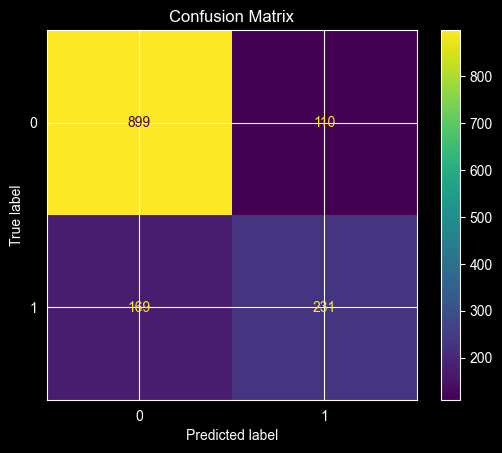

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

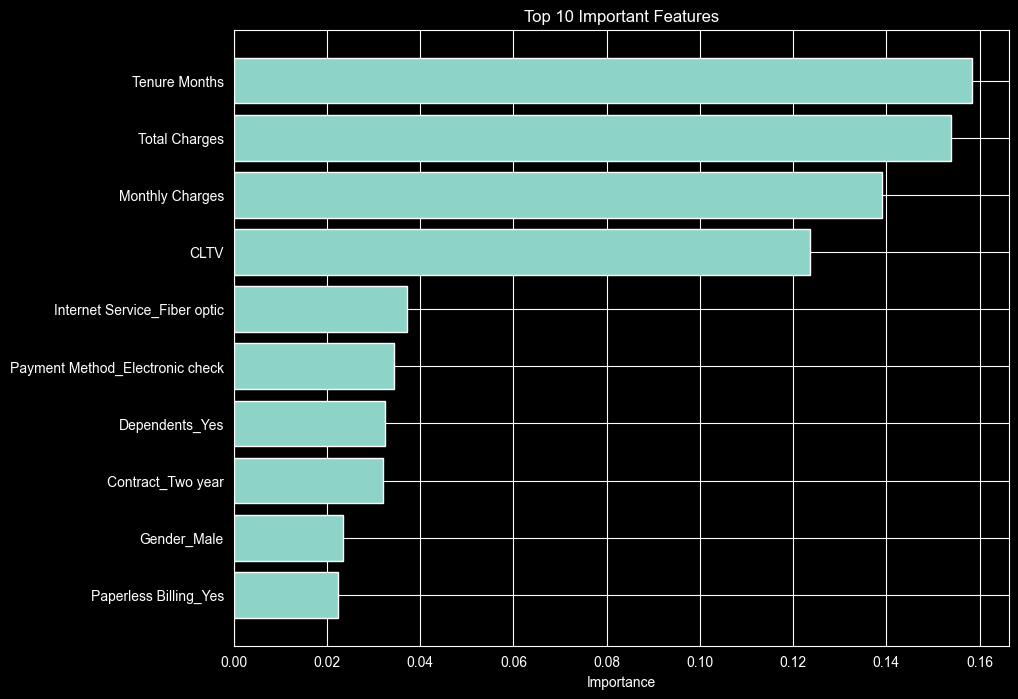

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()

plt.show()

In [85]:
X.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='str')

In [86]:
[col for col in X.columns if "Churn" in col]

[]

In [87]:
[col for col in X.columns if "Reason" in col]

[]

In [88]:
[col for col in X.columns if "Score" in col]

[]

In [89]:
print(df["Total Charges"].dtype)

float64


In [90]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"] = df["Total Charges"].fillna(df["Total Charges"].median())

In [91]:
print(df["Total Charges"].dtype)
print(len(X.columns))

float64
31


In [92]:
y = df["Churn Label"]
X = df.drop("Churn Label", axis=1)

In [93]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [94]:
X = pd.get_dummies(X, drop_first=True)

In [95]:
print(len(X.columns))

31


In [96]:
print(df.dtypes)

Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges        float64
Churn Label              str
CLTV                   int64
dtype: object


In [97]:
import joblib

joblib.dump(model, "../models/churn_model.pkl")   # or rf_model if Random Forest is best
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [98]:
[col for col in X.columns if "Churn" in col]

[]

In [99]:
import joblib

joblib.dump(rf_model, "../models/churn_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [100]:
print(X.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes', 'Phone Service_Yes', 'Multiple Lines_No phone service', 'Multiple Lines_Yes', 'Internet Service_Fiber optic', 'Internet Service_No', 'Online Security_No internet service', 'Online Security_Yes', 'Online Backup_No internet service', 'Online Backup_Yes', 'Device Protection_No internet service', 'Device Protection_Yes', 'Tech Support_No internet service', 'Tech Support_Yes', 'Streaming TV_No internet service', 'Streaming TV_Yes', 'Streaming Movies_No internet service', 'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year', 'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


In [101]:
import joblib

joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [102]:
type(rf_model)

sklearn.ensemble._forest.RandomForestClassifier

In [103]:
import joblib

joblib.dump(rf_model, "../models/churn_model.pkl")
joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [104]:
rf_model.n_features_in_

31

In [105]:
print(len(X.columns))
print(rf_model.n_features_in_)


31
31


In [106]:
import joblib

joblib.dump(rf_model, "../models/churn_model.pkl")
joblib.dump(X.columns.tolist(), "../models/features.pkl")

['../models/features.pkl']

In [107]:
print(len(X.columns))
print(rf_model.n_features_in_)


31
31
